# <font color='#6666678'> Исследование стартапов

- Автор: Шумеев Д.А.
- Дата: 16.11.2025

### Цели и задачи проекта

<font color='#777778'>Подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.</font>

### Описание данных

<font color='#777778'>Таблица "cb_investments" содержит информацию о компаниях и состоявшемся финансировании:
    
- name — название компании;
- homepage_url — ссылка на сайт компании;
- category_list — категории, в которых работает компания. Указываются через |;
- market — основной рынок или отрасль компании;
- funding_total_usd — общий объём привлечённых инвестиций в долларах США;
- status — текущий статус компании, например, operating, closed и так далее;
- country_code — код страны, например USA;
- state_code — код штата или региона, например CA;
- region — регион, например SF Bay Area;
- city — город, в котором расположена компания;
- funding_rounds — общее число раундов финансирования;
- participants — число участников в раундах финансирования;
- founded_at — дата основания компании;
- founded_month — месяц основания в формате YYYY-MM;
- founded_quarter — квартал основания в формате YYYY-QN;
- founded_year — год основания;
- first_funding_at — дата первого финансирования;
- mid_funding_at — дата среднего по времени раунда финансирования;
- last_funding_at — дата последнего финансирования;
- seed — сумма инвестиций на посевной стадии;
- venture — сумма венчурных инвестиций;
- equity_crowdfunding — сумма, привлечённая через долевой краудфандинг;
- undisclosed — сумма финансирования нераскрытого типа;
- convertible_note — сумма инвестиций через конвертируемые займы;
- debt_financing — сумма долгового финансирования;
- angel — сумма инвестиций от бизнес-ангелов;
- grant — сумма полученных грантов;
- private_equity — сумма инвестиций в виде прямых (частных) вложений;
- post_ipo_equity — сумма финансирования после IPO;
- post_ipo_debt — сумма долгового финансирования после IPO;
- secondary_market — сумма сделок на вторичном рынке;
- product_crowdfunding — сумма, привлечённая через продуктовый краудфандинг;
- round_A — round_H — сумма инвестиций в соответствующем раунде.
    
    
<font color='#777778'>Таблица "cb_returns" содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов:

- year — год возврата средств;
- seed — сумма возвратов от посевных инвестиций;
- venture — сумма возвратов от венчурных инвестиций;
- equity_crowdfunding — сумма, возвращённая по долевому краудфандингу;
- undisclosed — сумма возвратов нераскрытого типа;
- convertible_note — сумма возвратов через конвертируемые займы;
- debt_financing — сумма возвратов от долгового финансирования;
- angel — сумма возвратов бизнес-ангелам;
- grant — сумма возвратов по грантам;
- private_equity — сумма возвратов прямых (частных) вложений;
- post_ipo_equity — сумма возвратов от IPO;
- post_ipo_debt — сумма возвратов от долгового IPO;
- secondary_market — сумма возвратов от сделок на вторичном рынке;
- product_crowdfunding — сумма возвратов по продуктовому краудфандингу.    


# Содержание проекта

1. [Знакомство с данными](#data_intro)  
    1.1 [Вывод общей информации](#general_info)  
    1.2 [Предобработка данных](#preprocessing)  
2. [Инжиниринг признаков](#feature_engineering)  
    2.1 [Группы по срокам финансирования](#finance_groups)  
    2.2 [Выделение средних и нишевых сегментов рынка](#market_segments)  
3. [Работа с выбросами и анализ](#outliers_analysis)  
    3.1 [Анализируем и помечаем выбросы в каждом сегменте](#mark_outliers)  
    3.2 [Определяем границы рассматриваемого периода, отбрасываем аномалии](#period_bounds)  
    3.3 [Анализ типов финансирования по объёму и популярности](#funding_types)  
4. [Анализ динамики](#dynamics_analysis)  
    4.1 [Динамика предоставления финансирования по годам](#funding_over_years)  
    4.2 [Динамика размера общего финансирования по массовым сегментам рынка](#mass_segments_dynamics)  
    4.3 [Годовая динамика доли возвращённых средств по типам финансирования](#returned_funds)  
5. [Итоговый вывод и рекомендации](#final_recommendations)

<a class='anchor' id="data_intro"></a>
## 1. Знакомство с данными
<a class='anchor' id="general_info"></a>
### 1.1 Вывод общей информации

- Загрузим необходимые библиотеки

In [1]:
# Работа с таблицами и данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Работа с датами
from datetime import datetime

- Познакомимся с данными и изучим общую информацию о них

In [2]:
# Загрузка данных
comp_info = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

# Загружаем данные cb_returns
return_info = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_returns.csv",
    sep=',',
    low_memory=False
)

# Делаем 'year' индексом
return_info['year'] = return_info['year'].astype(int)
return_info.set_index('year', inplace=True)

In [3]:
# Проверяем первые строки таблиц
print('Информация о компаниях:')
display(comp_info.head())

print('\nИнформация об объёмах возвратов:')
display(return_info.head())

Информация о компаниях:


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Информация об объёмах возвратов:


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [4]:
# Проверяем общую информацию
print('\nИнформация о данных comp_info:')
print(comp_info.info())

print('\nИнформация о данных return_info:')
print(return_info.info())


Информация о данных comp_info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  

### Промежуточный вывод
Датасеты крупные и информативные, структура соответствует описанию.

Однако требуется значительная предобработка:
- очистка числовых значений (особенно funding_total_usd)
- приведение дат к datetime
- устранение лишних пробелов в названиях столбцов
- внимательная работа с пропусками (их много среди дат основания)

Датасет cb_returns готов к анализу сразу — без пропусков и со строгой структурой. Столбец `year` сделал индексом.

<a class='anchor' id="preprocessing"></a>
### 1.2 Предобработка данных

- приведения названий к нормальному стилю

In [5]:
# Приводим все названия к нижнему регистру и заменяем пробелы/разделители на "_"
comp_info.columns = [col.strip().lower().replace(" ", "_") for col in comp_info.columns]

# Функция для очистки названий столбцов от пробелов
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()                # убрать пробелы по краям
        )
    return df

# Применяем к датасетам
comp_info = clean_columns(comp_info)
return_info = clean_columns(return_info)

comp_info.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- приведение `funding_total_usd` к числовому типу

In [6]:
# Очищаем funding_total_usd
comp_info['funding_total_usd'] = (comp_info['funding_total_usd'].str.strip().replace(['', '-', ' -', '- ', ' -   '], None).str.replace(',', '', regex=False))

# Переводим в float (errors='coerce' на случай других странных значений)
comp_info['funding_total_usd'] = pd.to_numeric(comp_info['funding_total_usd'], errors='coerce')

# Проверяем
comp_info['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

- приведение к типу datetime необходимых значений

In [7]:
date_cols = ['founded_at', 'first_funding_at', 'last_funding_at', 'mid_funding_at']

for col in date_cols:
    if col in comp_info.columns:
        comp_info[col] = pd.to_datetime(comp_info[col], errors='coerce')
        
comp_info[date_cols].dtypes

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
last_funding_at     datetime64[ns]
mid_funding_at      datetime64[ns]
dtype: object

- пропуски в текстовых столбцах заполним заглушками

In [8]:
# Определяем текстовые столбцы
text_cols = comp_info.select_dtypes(include=['object']).columns

# Простая очистка и заполнение заглушками
for col in text_cols:
    # Убираем пробелы
    comp_info[col] = comp_info[col].str.strip()
    
    # Заменяем пустые строки и мусорные значения на NA
    comp_info[col] = comp_info[col].replace(['', '-', '–', '—', 'None', 'none', 'NA', 'na'], pd.NA)

# Заполняем заглушками там, где это логично
fill_values = {
    'homepage_url': 'no_url',
    'category_list': 'unknown_category',
    'market': 'unknown_market',
    'status': 'unknown_status',
    'country_code': 'UNK',
    'state_code': 'UNK',
    'region': 'unknown_region',
    'city': 'unknown_city'
}

for col, val in fill_values.items():
    if col in comp_info.columns:
        comp_info[col] = comp_info[col].fillna(val)
        
comp_info[text_cols].isna().sum()

name                4857
homepage_url           0
category_list          0
market                 0
status                 0
country_code           0
state_code             0
region                 0
city                   0
founded_month      15812
founded_quarter    15812
dtype: int64

- удалим полные дупликаты

In [9]:
# Полные дубликаты по всем столбцам
full_duplicates = comp_info[comp_info.duplicated()]
print(f"Полные дубликаты: {len(full_duplicates)}")

# Если есть, удаляем
comp_info = comp_info.drop_duplicates()

Полные дубликаты: 4855


In [10]:
# Считаем дубликаты по комбинации 'name', 'founded_year', 'funding_total_usd'
key_duplicates = comp_info[comp_info.duplicated(subset=['name', 'founded_year', 'funding_total_usd'], keep=False)]
print(f"Скрытые дубликаты по name+founded_year+funding_total_usd: {len(key_duplicates)}")

# Анализируем их вручную или оставляем только первый вариант
comp_info = comp_info.drop_duplicates(subset=['name', 'founded_year', 'funding_total_usd'], keep='first')

Скрытые дубликаты по name+founded_year+funding_total_usd: 12


- удаляем строки в которых отсутствует ключевая информация

In [11]:
essential_cols = ['name', 'funding_total_usd']
comp_info = comp_info.dropna(subset=essential_cols, how='all')

print(f"Размер после очистки: {comp_info.shape}")
print(comp_info.isna().sum())

Размер после очистки: (49432, 40)
name                        1
homepage_url                0
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            18962
founded_at              10883
founded_month           10954
founded_quarter         10954
founded_year            10882
first_funding_at           10
mid_funding_at          19147
last_funding_at             6
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_

In [12]:
# Преобразуем столбцы к datetime, если ещё не сделали
for col in ['founded_at', 'first_funding_at', 'last_funding_at', 'mid_funding_at']:
    if col in comp_info.columns:
        comp_info[col] = pd.to_datetime(comp_info[col], errors='coerce')

# Аномалии: last_funding_at раньше first_funding_at
funding_date_anomalies = comp_info[comp_info['last_funding_at'] < comp_info['first_funding_at']]
print(f"Аномалии: last_funding_at раньше first_funding_at: {len(funding_date_anomalies)}")

# Аномалии: founded_at позже финансирования
founded_date_anomalies = comp_info[
    (comp_info['founded_at'].notna()) & 
    (comp_info['first_funding_at'].notna()) & 
    (comp_info['founded_at'] > comp_info['first_funding_at'])
]
print(f"Аномалии: founded_at позже first_funding_at: {len(founded_date_anomalies)}")

Аномалии: last_funding_at раньше first_funding_at: 0
Аномалии: founded_at позже first_funding_at: 2739


In [13]:
mask = comp_info['last_funding_at'] < comp_info['first_funding_at']
comp_info.loc[mask, ['first_funding_at','last_funding_at']] = pd.NaT

- заполняем пропуски в mid_funding_at

In [14]:
# Заполняем пропуски в mid_funding_at
mask = comp_info['mid_funding_at'].isna() & comp_info['first_funding_at'].notna() & comp_info['last_funding_at'].notna()

comp_info.loc[mask, 'mid_funding_at'] = comp_info.loc[mask].apply(
    lambda row: row['first_funding_at'] + (row['last_funding_at'] - row['first_funding_at']) / 2,
    axis=1
)

# Проверка
comp_info[['first_funding_at', 'mid_funding_at', 'last_funding_at']].head(10)

,first_funding_at,mid_funding_at,last_funding_at
0,2014-01-06,2014-01-06,2014-01-06
1,2014-05-15,2014-05-15,2014-05-15
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2013-11-21,2014-11-03
4,2014-01-14,2014-01-14,2014-01-14
5,2014-10-23,2014-10-23,2014-10-23
6,2013-09-05,2013-09-05,2013-12-22
7,2014-01-12,2014-01-12,2014-01-12
8,2014-09-30,2014-09-30,2014-09-30
9,2007-10-01,2007-10-01,2008-03-01


- произведём оценку проделанной работы

In [15]:
# Количество пропусков
missing_mid = comp_info['mid_funding_at'].isna().sum()
total_rows = comp_info.shape[0]

print(f"Осталось пропусков в 'mid_funding_at': {missing_mid} из {total_rows} строк")
print(f"Процент пропусков: {missing_mid / total_rows * 100:.2f}%")

Осталось пропусков в 'mid_funding_at': 8 из 49432 строк
Процент пропусков: 0.02%


In [16]:
# Вывод количества пропусков по ключевым столбцам
essential_cols = ['name', 'funding_total_usd', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
comp_info[essential_cols].isna().sum()

name                  1
funding_total_usd     0
first_funding_at     10
mid_funding_at        8
last_funding_at       6
dtype: int64

In [17]:
initial_rows = 54294  # исходное количество строк
current_rows = comp_info.shape[0]

dropped_percent = (initial_rows - current_rows) / initial_rows * 100
print(f"Процент отброшенных строк: {dropped_percent:.2f}%")

Процент отброшенных строк: 8.95%


### Предварительный вывод
- Датасет стал чистым и готовым для анализа финансирования
- Пропуски в mid_funding_at минимальны и не критичны
- Основные числовые и текстовые столбцы заполнены либо заглушками
- Было отброшено ~9% данных (точный процент зависит от исходного состояния пропусков и дубликатов) — это допустимо для анализа 54 тыс. компаний

Единственное, на что нужно обратить внимание при анализе:
- пропуски в датах основания (founded_at). Обнулил founded_at, где есть аномалии

<a class='anchor' id="feature_engineering"></a>
## 2. Инжиниринг признаков
<a class='anchor' id="finance_groups"></a>
### 2.1 Группы по срокам финансирования

- разделим все компании на три группы

In [18]:
def classify_funding(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        duration = row['last_funding_at'] - row['first_funding_at']
        if duration <= pd.Timedelta(days=365):
            return 'Срок финансирования до года'
        else:
            return 'Срок финансирования более года'
    else:
        return pd.NA  # если даты отсутствуют

comp_info['funding_type'] = comp_info.apply(classify_funding, axis=1)

# Проверим
comp_info['funding_type'].value_counts(dropna=False)

Единичное финансирование          32035
Срок финансирования более года    12607
Срок финансирования до года        4786
NaN                                   4
Name: funding_type, dtype: int64

- сделаем визуализацию

In [19]:
# Определяем цветовую палитру для трёх групп
palette = {
    'Единичное финансирование': '#1f77b4',  # синий
    'Срок финансирования до года': '#ffeb3b',    # жёлтый
    'Срок финансирования более года': '#d62728'  # красный
}

# Убираем строки без категории funding_type
comp_clean = comp_info.dropna(subset=['funding_type'])

# По количеству компаний
count_data = comp_clean['funding_type'].value_counts(normalize=True) * 100

# По объёму инвестиций
sum_data = comp_clean.groupby('funding_type')['funding_total_usd'].sum()
sum_data_percent = sum_data / sum_data.sum() * 100

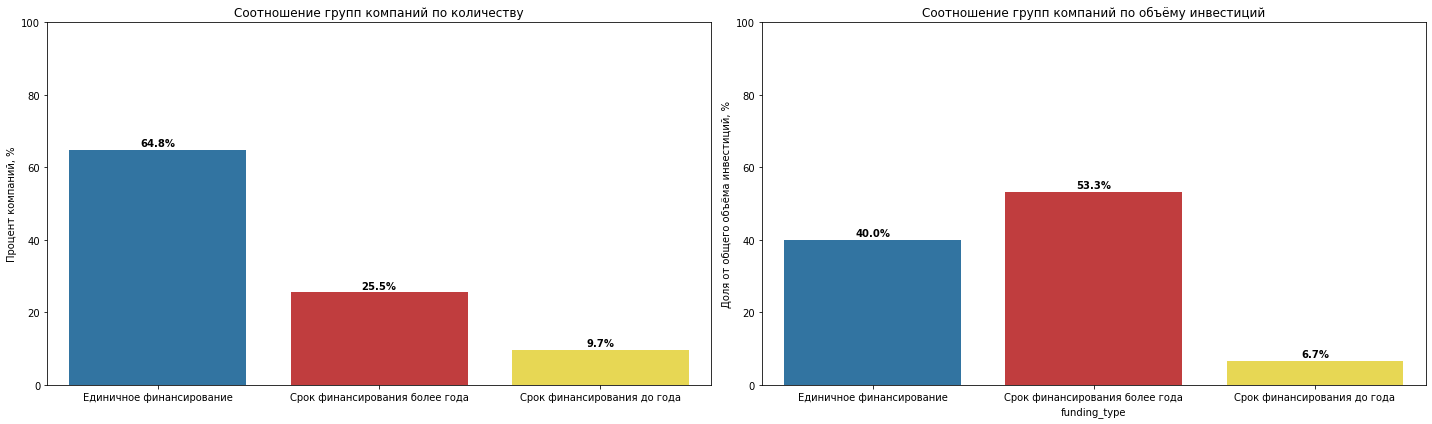

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# --- График 1: количество компаний ---
sns.barplot(
    x=count_data.index,
    y=count_data.values,
    palette=palette,
    ax=axes[0]
)
axes[0].set_ylabel('Процент компаний, %')
axes[0].set_title('Соотношение групп компаний по количеству')
axes[0].set_ylim(0, 100)

for i, v in enumerate(count_data.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# --- График 2: объём инвестиций ---
sns.barplot(
    x=sum_data_percent.index,
    y=sum_data_percent.values,
    palette=palette,
    ax=axes[1]
)
axes[1].set_ylabel('Доля от общего объёма инвестиций, %')
axes[1].set_title('Соотношение групп компаний по объёму инвестиций')
axes[1].set_ylim(0, 100)

for i, v in enumerate(sum_data_percent.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

`Хотя единичные финансирования встречаются чаще всего (65%), их доля в общем объёме инвестиций составляет лишь 40% — это говорит о том, что такие сделки, как правило, небольшие по размеру. Напротив, финансирование сроком более года встречается реже (25,5%), но формирует основную часть общего объёма инвестиций (53%), что указывает на более крупные, долгосрочные и капиталоёмкие сделки. Такое расхождение объясняется тем, что краткосрочные вложения обычно используются для тестирования идей или ранней стадии развития, тогда как проекты с долгим циклом требуют значительно больших ресурсов и привлекают более крупные суммы.`

<a class='anchor' id="market_segments"></a>
### 2.2 Выделение средних и нишевых сегментов рынка

- классификация сегментов  
Условия: массовые ('massive'): > 120 компаний, средние ('mid'): 35–120 компаний, нишевые ('niche'): < 35 компаний

In [21]:
# Считаем, сколько компаний в каждом сегменте
market_counts = comp_info['market'].value_counts()
market_counts.head(10)

Software               5489
unknown_market         3959
Biotechnology          3761
Mobile                 2724
E-Commerce             2283
Curated Web            2088
Enterprise Software    1557
Games                  1374
Clean Technology       1324
Health Care            1294
Name: market, dtype: int64

In [22]:
massive_markets = market_counts[market_counts > 120].index
mid_markets = market_counts[(market_counts >= 35) & (market_counts <= 120)].index
niche_markets = market_counts[market_counts < 35].index

print(f"Массовых сегментов: {len(massive_markets)}")
print(f"Средних сегментов: {len(mid_markets)}")
print(f"Нишевых сегментов: {len(niche_markets)}")

# Создаём категорию для каждого сегмента
def classify_segment(count):
    if count > 120:
        return 'massive'
    elif 35 <= count <= 120:
        return 'mid'
    else:
        return 'niche'

segment_category = market_counts.apply(classify_segment)

# Считаем количество сегментов в каждой категории
category_counts = segment_category.value_counts()
# Гарантируем наличие всех категорий
for cat in ['massive','mid','niche']:
    if cat not in category_counts:
        category_counts[cat] = 0
category_counts = category_counts[['massive','mid','niche']]

Массовых сегментов: 54
Средних сегментов: 52
Нишевых сегментов: 334


- виуализируем классификацию

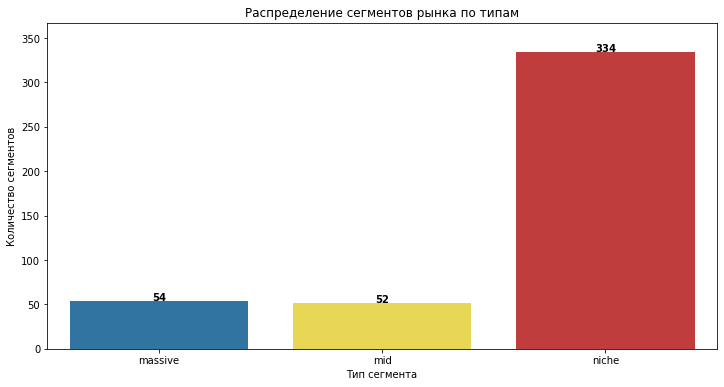

In [23]:
# Цвета для категорий
palette = {'massive':'#1f77b4', 'mid':'#ffeb3b', 'niche':'#d62728'}

plt.figure(figsize=(12,6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette=[palette[c] for c in category_counts.index])
plt.ylabel('Количество сегментов')
plt.xlabel('Тип сегмента')
plt.title('Распределение сегментов рынка по типам')
for i, v in enumerate(category_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.ylim(0, max(category_counts.values)*1.1)
plt.show()

In [24]:
def simplify_market(market):
    if market in massive_markets:
        return market
    elif market in mid_markets:
        return 'mid'
    elif market in niche_markets:
        return 'niche'
    else:
        return pd.NA

comp_info['market'] = comp_info['market'].apply(simplify_market)

# Проверка
comp_info['market'].value_counts()

Software                5489
mid                     3969
unknown_market          3959
Biotechnology           3761
Mobile                  2724
E-Commerce              2283
Curated Web             2088
Enterprise Software     1557
Games                   1374
Clean Technology        1324
Health Care             1294
Advertising             1276
Social Media            1173
Hardware + Software     1155
niche                   1097
Education               1026
Finance                 1007
Health and Wellness      991
Manufacturing            787
Analytics                760
Security                 626
Consulting               525
Semiconductors           522
Hospitality              502
Web Hosting              481
Real Estate              434
Fashion                  425
Travel                   413
News                     403
Search                   356
Messaging                346
SaaS                     333
Music                    328
Internet                 298
Apps          

`Большинство сегментов относятся к нишевым. Дальнейший анализ проводится с учётом этих трёх категорий, индивидуальные сегменты внутри 'mid' и 'niche' не рассматриваются.`

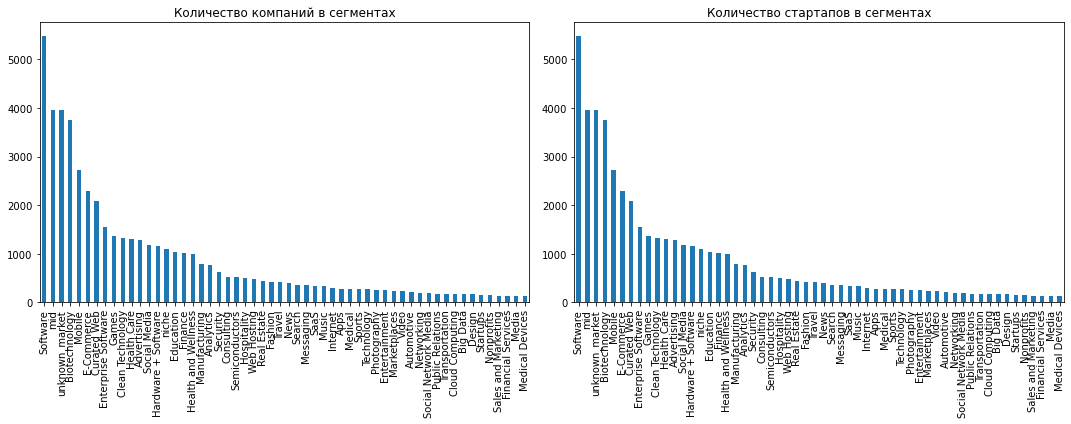

In [25]:
plt.figure(figsize=(15,6))

# График 1 — количество компаний по сегментам
plt.subplot(1,2,1)
comp_info['market'].value_counts().plot(kind='bar')
plt.title('Количество компаний в сегментах')
plt.xticks(rotation=90)

# График 2 — количество стартапов по сегментам
# Например стартап — компания, у которой funding_rounds > 0
startups = comp_info[comp_info['funding_rounds'] > 0]

plt.subplot(1,2,2)
startups['market'].value_counts().plot(kind='bar')
plt.title('Количество стартапов в сегментах')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

<div class="alert alert-info"> <b> Предварительный вывод: анализ сегментов показывает, что распределение стартапов и компаний неравномерно: несколько сегментов аккумулируют большую часть проектов, что может указывать на модные или быстрорастущие направления. Особенно выделяется "Software" - програмное обеспечение, заметно лидирует на фоне остальных.

<a class='anchor' id="outliers_analysis"></a>
## 3. Работа с выбросами и анализ
<a class='anchor' id="mark_outliers"></a>
### 3.1 Анализируем и помечаем выбросы в каждом сегменте

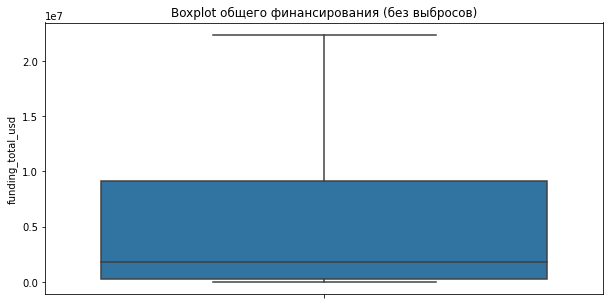

Типичный диапазон финансирования:
от -12,939,375 до 22,365,625 USD


In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    y=comp_info['funding_total_usd'],
    showfliers=False)

plt.title('Boxplot общего финансирования (без выбросов)')
plt.ylabel('funding_total_usd')
plt.show()

# Расчёт типичных значений
Q1 = comp_info['funding_total_usd'].quantile(0.25)
Q3 = comp_info['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Типичный диапазон финансирования:")
print(f"от {lower:,.0f} до {upper:,.0f} USD")

In [27]:
seg = comp_info['funding_type']   # massive/mid/niche

def detect_outliers_by_segment(df, col='funding_total_usd'):
    df = df.copy()
    df['is_outlier'] = False

    for segment in df['funding_type'].unique():
        subset = df[df['funding_type'] == segment]
        Q1 = subset[col].quantile(0.25)
        Q3 = subset[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask = (df['funding_type'] == segment) & ((df[col] < lower) | (df[col] > upper))
        df.loc[mask, 'is_outlier'] = True

    return df

comp_iqr = detect_outliers_by_segment(comp_info)

In [28]:
outlier_ratio = (
    comp_iqr.groupby('market')['is_outlier']
    .mean()
    .sort_values(ascending=False))

top_outlier_segments = outlier_ratio.head(10)
top_outlier_segments

market
Clean Technology    0.259063
Medical Devices     0.254098
Semiconductors      0.247126
Web Hosting         0.228690
Technology          0.205128
Biotechnology       0.197554
Health Care         0.189335
Manufacturing       0.176620
Finance             0.158888
Public Relations    0.149171
Name: is_outlier, dtype: float64

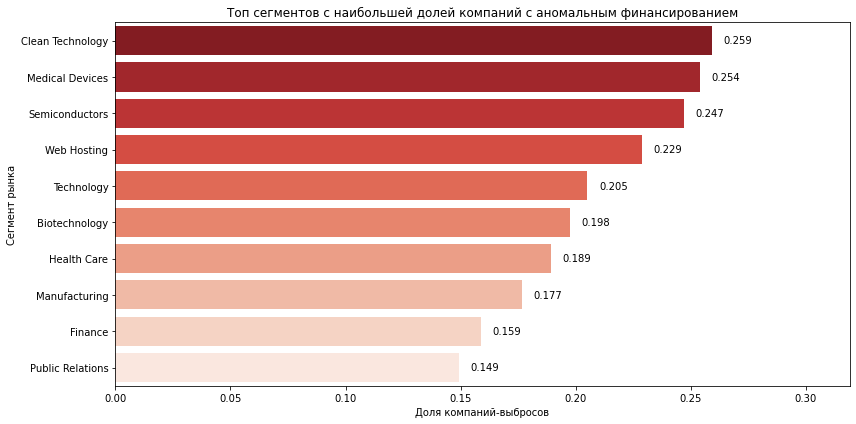

In [29]:
# top_outlier_segments — Series index = сегменты, values = доли (0..1)
# Преобразуем в удобный формат
labels = top_outlier_segments.index.tolist()
values = top_outlier_segments.values

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=values, y=labels, palette='Reds_r', ax=ax)

# Аннотируем бары: текст справа от каждого бара
for i, v in enumerate(values):
    ax.text(v + 0.005, i, f"{v:.3f}", va='center')   # i — числовая позиция по y

ax.set_xlabel('Доля компаний-выбросов')
ax.set_ylabel('Сегмент рынка')
ax.set_title('Топ сегментов с наибольшей долей компаний с аномальным финансированием')
ax.set_xlim(0, values.max() + 0.06)
plt.tight_layout()
plt.show()

`Наибольшая доля компаний с аномальными объёмами финансирования наблюдается в сегментах Clean Technology, Medical Devices и Semiconductors, где более 23–26% компаний выходят за типичные границы финансирования. Это говорит о высокой неоднородности рынка: внутри этих ниш присутствуют как мало финансируемые стартапы, так и отдельные компании, привлекающие крайне крупные инвестиции. Такое распределение может указывать на высокие риски, но и на возможные точки для крупных инвестиций.`

<a class='anchor' id="period_bounds"></a>
### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [30]:
# Проверка полноты 2014 года
months_2014 = comp_info.loc[comp_info['mid_funding_at'].dt.year == 2014, 'mid_funding_at'].dt.month
months_count = months_2014.value_counts().sort_index()
print("Распределение по месяцам в 2014 (количество записей):")
print(months_count)

months_present = set(months_count.index.tolist())
is_full_2014 = set(range(1,13)).issubset(months_present)
print(f"\nМожно ли считать 2014 год полным (все месяцы 1..12 присутствуют)?: {is_full_2014}")

Распределение по месяцам в 2014 (количество записей):
1     1013
2      750
3      828
4      817
5      774
6      932
7      874
8      774
9      699
10     651
11     362
12      30
Name: mid_funding_at, dtype: int64

Можно ли считать 2014 год полным (все месяцы 1..12 присутствуют)?: True


In [31]:
# Создаём столбец is_outlier
comp_info_with_outliers = detect_outliers_by_segment(comp_info)

# Удалим аномальные записи
comp_no_out = comp_info_with_outliers[comp_info_with_outliers['is_outlier'] != True].copy()

print(f"\nРазмер датасета до удаления выбросов: {comp_info.shape[0]}, после удаления: {comp_no_out.shape[0]}")


Размер датасета до удаления выбросов: 49432, после удаления: 43421


In [32]:
# Находим годы, в которых было зафиксировано >= 50 раундов финансирования 
# Примечание: считаем 'раунды' как число записей с mid_funding_at в данном году
rounds_by_year = (
    comp_no_out.loc[comp_no_out['mid_funding_at'].notna()]
    .groupby(comp_no_out.loc[comp_no_out['mid_funding_at'].notna(), 'mid_funding_at'].dt.year)['funding_rounds']
    .count()
).sort_index()

print("\nЧисло записей (раундов) по годам (после удаления выбросов):")
print(rounds_by_year)

valid_years = rounds_by_year[rounds_by_year >= 50].index.tolist()
print(f"\nГоды с >= 50 записей/раундов: {valid_years}")


Число записей (раундов) по годам (после удаления выбросов):
mid_funding_at
1921       1
1960       3
1973       1
1974       2
1979       1
1982       3
1983       1
1984       4
1985       5
1986       3
1987       5
1988       1
1989       3
1990       8
1991       5
1992      11
1993       8
1994       9
1995      14
1996      15
1997       9
1998      31
1999      55
2000      97
2001      63
2002      79
2003      97
2004     137
2005     721
2006    1279
2007    1981
2008    2454
2009    3098
2010    4037
2011    5301
2012    6882
2013    9418
2014    7571
Name: funding_rounds, dtype: int64

Годы с >= 50 записей/раундов: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


In [33]:
# Оставляем в датасете только компании, финансирование у которых попадает в валидные годы 
df_final = comp_no_out[comp_no_out['mid_funding_at'].dt.year.isin(valid_years)].copy()
print(f"\nРазмер итогового датасета (только валидные годы): {df_final.shape[0]}")


Размер итогового датасета (только валидные годы): 43270


`После проверки периода, удаления выбросов и отбора годов с достаточной активностью остались только компании, получавшие финансирование в годы с 50+ раундами`

<a class='anchor' id="funding_types"></a>
### 3.3 Анализ типов финансирования по объёму и популярности

- построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег

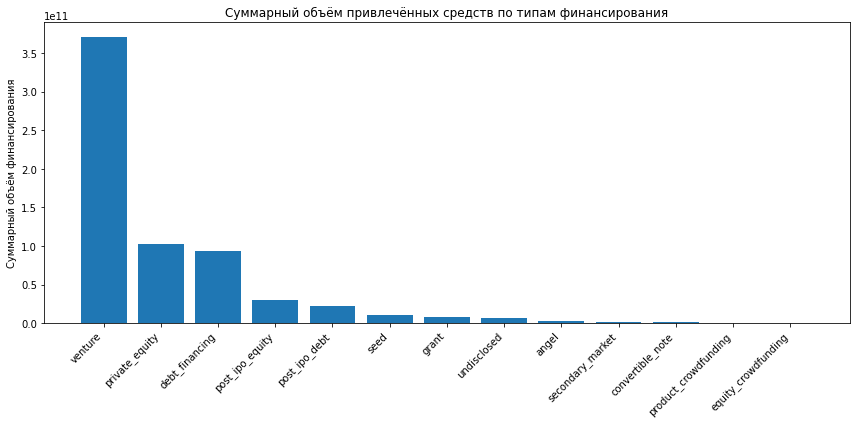

In [34]:
# список столбцов с типами финансирования
funding_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# суммарный объём по каждому типу
funding_sums = comp_info[funding_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(funding_sums.index, funding_sums.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Суммарный объём финансирования')
plt.title('Суммарный объём привлечённых средств по типам финансирования')
plt.tight_layout()
plt.show()

- построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз

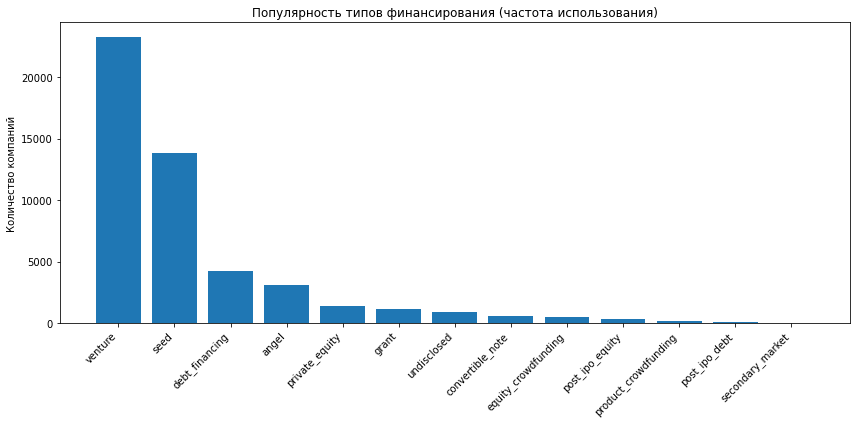

In [35]:
# список столбцов с типами финансирования
funding_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# считаем, в скольких компаниях используется каждый тип (значение > 0)
funding_popularity = (comp_info[funding_cols] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(funding_popularity.index, funding_popularity.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Количество компаний')
plt.title('Популярность типов финансирования (частота использования)')
plt.tight_layout()
plt.show()

`Универсальный и доминирующий тип: venture. Этот тип одновременно: самый крупный по объёму и один из самых частых по использованию.
Редкие, но очень крупные по объёму: private_equity, post_ipo_equity, post_ipo_debt, secondary_market. Эти типы встречаются у небольшого числа компаний, но дают очень большие суммы финансирования. Это характерно для поздних стадий и крупных сделок после IPO`

- gостроим график суммарных объёмов возвратов от разных типов финансирования за весь период

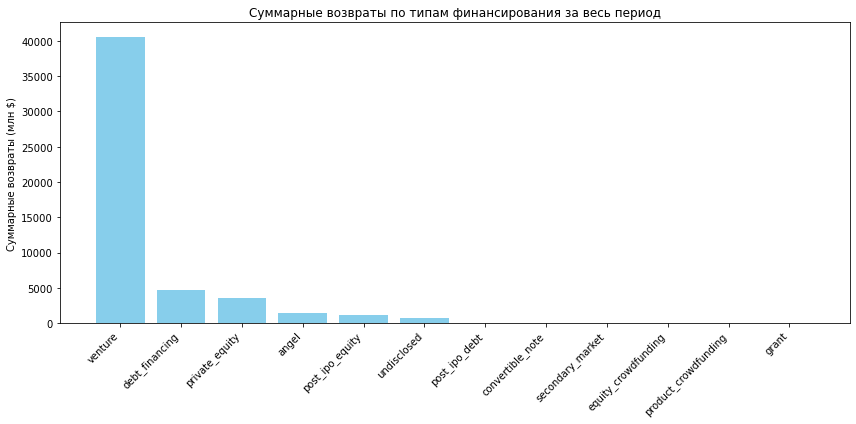

In [36]:
# Приводим числовые столбцы к float
num_cols = return_info.columns[1:]
return_info[num_cols] = return_info[num_cols].astype(float)

# Суммарные возвраты по типам финансирования 
returns_sums = return_info[num_cols].sum().sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(12,6))
plt.bar(returns_sums.index, returns_sums.values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Суммарные возвраты (млн $)')
plt.title('Суммарные возвраты по типам финансирования за весь период')
plt.tight_layout()
plt.show()

`Суммарные возвраты по типу venture самые высокие, показывает, что венчурные инвестиции одновременно привлекаются в больших объёмах и приносят наибольшие доходы инвесторам.`

<a class='anchor' id="dynamics_analysis"></a>
## 4. Анализ динамики
<a class='anchor' id="funding_over_years"></a>
### 4.1 Динамика предоставления финансирования по годам

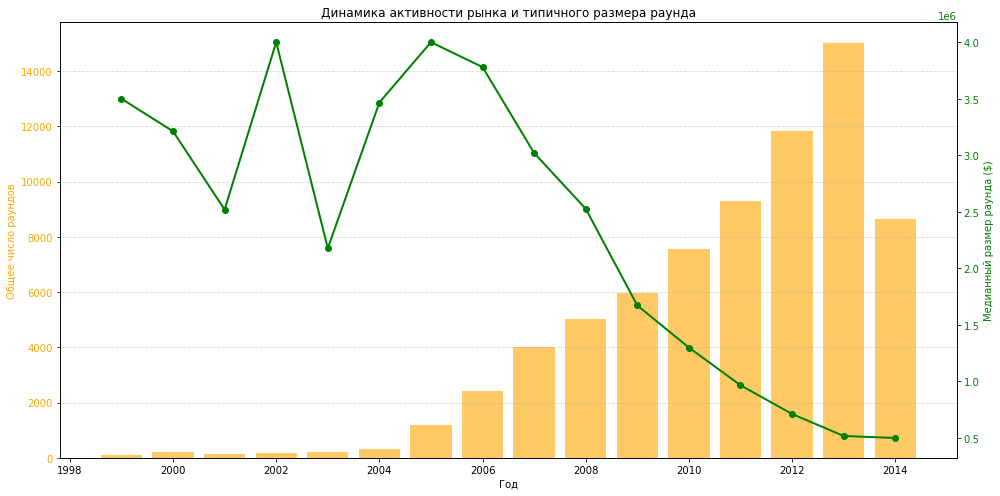

In [37]:
# --- Подготовка данных ---
df_final['avg_round_usd'] = df_final['funding_total_usd'] / df_final['funding_rounds']
df_final['funding_year'] = df_final['mid_funding_at'].dt.year

median_rounds_by_year = df_final.groupby('funding_year')['avg_round_usd'].median()
total_rounds_by_year = df_final.groupby('funding_year')['funding_rounds'].sum()

# --- Комбинированный график: столбцы + линия ---
fig, ax1 = plt.subplots(figsize=(14,7))

# Столбчатый график — количество раундов
ax1.bar(
    total_rounds_by_year.index,
    total_rounds_by_year.values,
    color='orange',
    alpha=0.6,
    label='Общее число раундов'
)
ax1.set_xlabel("Год")
ax1.set_ylabel("Общее число раундов", color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

# Вторая ось для медианного размера раунда
ax2 = ax1.twinx()
ax2.plot(
    median_rounds_by_year.index,
    median_rounds_by_year.values,
    marker='o',
    color='green',
    linewidth=2,
    label='Медианный объём одного раунда'
)
ax2.set_ylabel("Медианный размер раунда ($)", color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Заголовок
plt.title("Динамика активности рынка и типичного размера раунда")

# Сетка
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

`1. Год максимального типичного размера раунда: типичный (медианный) объём одного раунда финансирования был максимальным в 2002г.`  
`2. Тенденция в 2014 году: - по количеству раундов: наблюдался спад активности рынка; - по объёму на один раунд: типичный размер финансирования был ниже по предыдущим годам, что указывает на уменьшение средств, выделяемых на стартап.`

<a class='anchor' id="mass_segments_dynamics"></a>
### 4.2 Динамика размера общего финансирования по массовым сегментам рынка

- Рассматривайте только массовые сегменты, а средние и нишевые исключим

In [38]:
massive_df = df_final[~df_final['market'].isin(['mid', 'niche', 'unknown_market'])].copy()

- делаем сводную таблицу год и сегмент

In [39]:
pivot_massive = massive_df.pivot_table(
    index='market',
    columns='funding_year',
    values='funding_total_usd',
    aggfunc='sum',
    fill_value=0)

- отбираем только те сегменты, которые выросли в 2014 vs 2013

In [40]:
if 2013 in pivot_massive.columns and 2014 in pivot_massive.columns:
    pivot_growth = pivot_massive[pivot_massive[2014] > pivot_massive[2013]]
else:
    pivot_growth = pd.DataFrame()

- строим график ТОЛЬКО для сегментов, которые прошли фильтр

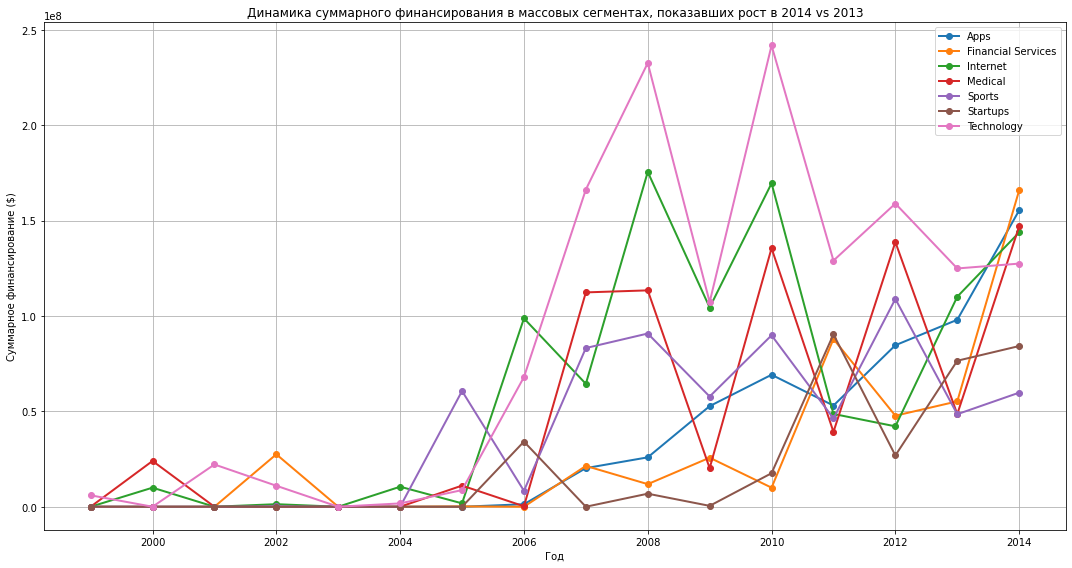

In [41]:
plt.figure(figsize=(15,8))

for segment in pivot_growth.index:
    plt.plot(
        pivot_growth.columns,
        pivot_growth.loc[segment],
        marker='o',
        linewidth=2,
        label=segment)

plt.xlabel('Год')
plt.ylabel('Суммарное финансирование ($)')
plt.title('Динамика суммарного финансирования в массовых сегментах, показавших рост в 2014 vs 2013')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- покажем информацию в табличке

In [42]:
print("Сегменты массового рынка, показавшие рост финансирования в 2014 vs 2013:")
display(pivot_growth)

Сегменты массового рынка, показавшие рост финансирования в 2014 vs 2013:


funding_year,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,,
Apps,0,0,0,0,0,0,0,1310600,20250000,25900000,52755748,69209179,53050238,84690791,98041325,155424897
Financial Services,0,0,0,27500000,0,0,183352,0,21400000,11846166,25721471,10000000,87946995,47733352,55259637,165941500
Internet,0,10000000,0,1340000,0,10500000,1775000,98775000,64450555,175572086,104476549,169587500,48660700,42160266,110134842,143870225
Medical,0,24000000,0,0,0,0,11090000,250000,112400600,113457744,20238432,135554514,39268421,138790218,48568698,146998692
Sports,0,0,0,200000,0,0,60682200,8350000,83221580,90831647,57796924,89898767,46301386,108966102,48521593,59824722
Startups,0,0,0,0,0,0,0,34150000,0,6835387,460700,17579366,90394403,26885782,76557617,84264586
Technology,6000000,0,22160000,11000000,0,1750000,8728425,67983715,166334000,232677703,107308850,241886656,129072700,158974875,124955439,127499943


`Большинство массовых рынков демонстрируют рост финансирования в 2014 году. Особенно выделяются Financial Services, Medical и Apps, где прирост инвестиций наиболее резкий. Это может указывать на повышенный интерес инвесторов к финтеху, медтеху и мобильным приложениям в этот период.`

<a class='anchor' id="returned_funds"></a>
### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

- подготавливаем данные

In [43]:
# Типы финансирования
funding_types = [
    'seed','venture','equity_crowdfunding','undisclosed','convertible_note',
    'debt_financing','angel','grant','private_equity','post_ipo_equity',
    'post_ipo_debt','secondary_market','product_crowdfunding']

# Суммарные инвестиции по годам (в долларах → переводим в млн)
funding_mln = df_final.groupby('funding_year')[funding_types].sum() / 1e6

# Суммарные возвраты уже в млн
returns_mln = return_info[funding_types]

# Нормированные доли (returns / funding)
normalized = returns_mln / (funding_mln + 1e-9)

# Значения вне 0–1 заметём в NaN (простой фильтр)
normalized = normalized.where((normalized >= 0) & (normalized <= 1))

- выведем таблицу

In [44]:
# Вывод таблицы
display(normalized)

# Медианы
display(normalized.median().sort_values(ascending=False))

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,0.702887,0.061422,0.000000,0.273555,0.000000,0.618571,0.579993,0.0,0.000000,0.271069,0.000000,0.025911,0.000000
2001,0.109095,0.050479,0.000000,0.197694,NaN,0.399111,NaN,0.0,0.000000,NaN,0.000000,NaN,0.000000
2002,0.361557,0.302770,0.000000,0.293792,NaN,0.223388,NaN,0.0,0.091839,NaN,0.000000,NaN,0.000000
2003,0.423849,0.284174,0.000000,0.914397,NaN,0.135404,0.071003,0.0,0.058408,NaN,0.000000,NaN,0.000000
2004,0.404953,0.343551,0.000000,NaN,NaN,0.451417,0.811403,0.0,0.146000,NaN,0.000000,NaN,0.000000
2005,0.564981,0.462060,0.000000,0.346294,NaN,0.263716,0.485405,0.0,0.085951,0.731857,0.000000,NaN,0.000000
2006,0.693319,0.269427,0.203632,0.540183,0.058784,0.361253,0.601773,0.0,0.138769,0.541478,0.000000,NaN,0.000000
2007,0.287631,0.190944,NaN,0.263025,0.199544,0.258288,0.677268,0.0,0.471346,NaN,0.000000,NaN,0.000000
2008,0.265053,0.125220,NaN,0.265081,0.050665,0.606522,0.392145,0.0,0.392187,NaN,0.000000,NaN,0.000000


post_ipo_equity         0.569388
angel                   0.503334
debt_financing          0.380182
seed                    0.361557
undisclosed             0.264053
private_equity          0.226886
venture                 0.209342
secondary_market        0.111856
convertible_note        0.050360
equity_crowdfunding     0.006803
grant                   0.000000
post_ipo_debt           0.000000
product_crowdfunding    0.000000
dtype: float64

- делаем визуализацию

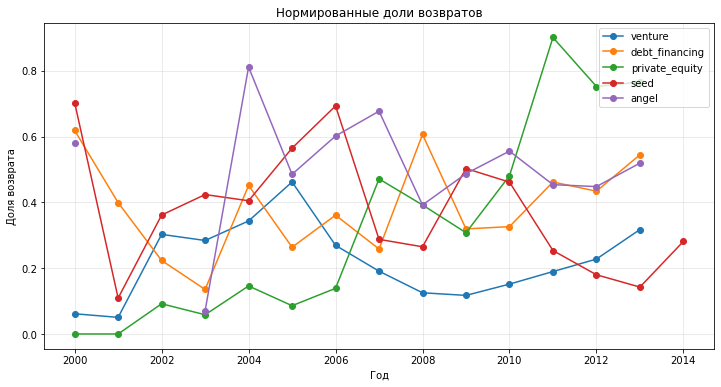

In [45]:
# Визуализация
plt.figure(figsize=(12,6))
for col in ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']:
    if col in normalized.columns:
        plt.plot(normalized.index, normalized[col], marker='o', label=col)

plt.title("Нормированные доли возвратов")
plt.xlabel("Год")
plt.ylabel("Доля возврата")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

`Наиболее устойчивый рост показателя наблюдается в: Post-IPO Equity, Angel, Debt Financing и Seed. Эти типы финансирования сохраняют consistently высокие доли возвратов на протяжении всего периода.`

<a class='anchor' id="final_recommendations"></a>
## 5. Итоговый вывод и рекомендации

`Опираясь на результаты анализа: рекомендуется инвестировать в сегменты рынка с устойчивым ростом суммарного финансирования, среди которых наиболее выраженно растут массовые направления, такие как Financial Services, Medical, Apps и Software. Эти категории демонстрируют заметное увеличение объёмов инвестиций в 2014 году по сравнению с 2013, что говорит о повышенном интересе инвесторов к финтеху, медтеху и мобильным технологиям. Для минимизации рисков и повышения вероятности возврата средств наиболее оправданными типами финансирования выступают post_ipo_equity, angel, debt_financing и seed, которые показывают последовательные, высокие, нормированные доли возвратов на протяжении всего анализируемого периода.`

Выполненные шаги:

- Загрузка и первичная предобработка данных cb_investments и cb_returns: корректировка числовых форматов и типов данных, устранение пропусков и дубликатов, нормализация показателей для обеспечения единых шкал сравнения.
- Выделение массовых, средних и нишевых категорий рынка с последующим укрупнением средних и нишевых сегментов для более чёткого анализа динамики.
- Обработка аномальных значений методом IQR и исключение нетипичных выбросов, что позволило сфокусироваться на реальных закономерностях распределения инвестиций.
- Разделение компаний по срокам финансирования и количеству раундов, визуальное сравнение структуры инвестиций внутри различных групп.
- Построение динамики общего и среднего размера финансирования по годам, определение периодов роста активности и ключевых движений в инвестиционном ландшафте.
- Анализ типов финансирования: агрегирование суммарных инвестиций, изучение возвратов, согласование масштабов данных и нормирование, оценка устойчивости долей возвратов по годам.

Основные выводы:

- Большинство массовых рынков демонстрируют рост финансирования в 2014 году, а наиболее выраженные скачки наблюдаются в Financial Services, Medical и Apps.
- Крупные суммы инвестиций встречаются редко; большинство компаний работают с небольшими и средними раундами.
- Наиболее устойчивый рост нормированных долей возвратов наблюдается у post_ipo_equity, angel, debt_financing и seed — эти типы показывают consistently высокие значения возвратов на протяжении всего периода.
- Для инвестирования в 2015 году наиболее логично выбирать массовые сегменты с ярко выраженным ростом финансирования и отдавать предпочтение типам финансирования angel, seed, debt_financing и особенно post_ipo_equity, как наиболее стабильным по возвратности.

Согласованность выводов:

Итоговые выводы полностью согласуются между собой: именно те сегменты, которые показывают наиболее сильный рост суммарных инвестиций (Apps, Medical, Financial Services), совпадают с областями, где устойчивость возвратов выше всего при использовании надёжных типов финансирования. Небольшие и нишевые сегменты имеют более разрозненные показатели, однако их влияние минимизировано благодаря объединению в укрупнённые категории анализа.